In [31]:
import pandas as pd
from bs4 import BeautifulSoup
import requests

web = "https://books.toscrape.com/"

print(web)

response = requests.get(web)
print(response.status_code)

soup = BeautifulSoup(response.text, "html.parser")

books = soup.find_all("article", class_="product_pod")

print(len(books))


https://books.toscrape.com/
200
20


In [32]:
print(books[0])

<article class="product_pod">
<div class="image_container">
<a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
</div>
<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
<div class="product_price">
<p class="price_color">Â£51.77</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>


In [33]:
premier_livre = books[0]

titre = premier_livre.find("h3")
print(titre)

<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>


In [34]:
lien = titre.find("a")
print(lien)

<a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a>


In [35]:
nom_livre = lien["title"]
print(nom_livre)

A Light in the Attic


In [36]:
for livre in books : 
    titres = livre.find("h3")
    liens = titres.find("a")
    noms_livres = liens["title"]
    print(noms_livres)
    

A Light in the Attic
Tipping the Velvet
Soumission
Sharp Objects
Sapiens: A Brief History of Humankind
The Requiem Red
The Dirty Little Secrets of Getting Your Dream Job
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics
The Black Maria
Starving Hearts (Triangular Trade Trilogy, #1)
Shakespeare's Sonnets
Set Me Free
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1)
Rip it Up and Start Again
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991
Olio
Mesaerion: The Best Science Fiction Stories 1800-1849
Libertarianism for Beginners
It's Only the Himalayas


In [37]:
prix = premier_livre.find(class_="price_color")
print(prix)

<p class="price_color">Â£51.77</p>


In [38]:
prix_ttc = prix.text
print(prix_ttc)

Â£51.77


In [39]:
for livre in books :
    titres = livre.find("h3")
    liens = titres.find("a")
    noms_livres = liens["title"]
    prix = livre.find("p",class_="price_color")
    prix_livres = prix.text
    print(noms_livres,prix_livres)

A Light in the Attic Â£51.77
Tipping the Velvet Â£53.74
Soumission Â£50.10
Sharp Objects Â£47.82
Sapiens: A Brief History of Humankind Â£54.23
The Requiem Red Â£22.65
The Dirty Little Secrets of Getting Your Dream Job Â£33.34
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull Â£17.93
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics Â£22.60
The Black Maria Â£52.15
Starving Hearts (Triangular Trade Trilogy, #1) Â£13.99
Shakespeare's Sonnets Â£20.66
Set Me Free Â£17.46
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1) Â£52.29
Rip it Up and Start Again Â£35.02
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991 Â£57.25
Olio Â£23.88
Mesaerion: The Best Science Fiction Stories 1800-1849 Â£37.59
Libertarianism for Beginners Â£51.33
It's Only the Himalayas Â£45.17


In [40]:
note = premier_livre.find("p", class_="star-rating")
print(note)

<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>


In [41]:
note["class"]

['star-rating', 'Three']

In [42]:
classes_note = note["class"]
note_livre = classes_note[1]
print(note_livre)

Three


In [43]:
conversion_notes = {
    "One" : 1,
    "Two" : 2,
    "Three" : 3,
    "Four" : 4,
    "Five" : 5
}

note_nombre = conversion_notes[note_livre]

print(note_nombre)

3


In [44]:
for livre in books :
    titres = livre.find("h3")
    liens = titres.find("a")
    noms_livres = liens["title"]
    note = livre.find("p", class_="star-rating")
    classes_note = note["class"]
    note_livre = classes_note[1]
    notes_nombre = conversion_notes[note_livre]
    prix = livre.find("p",class_="price_color")
    prix_livres = prix.text
    print(f"{noms_livres} | {prix_livres} | {note_nombre}")

A Light in the Attic | Â£51.77 | 3
Tipping the Velvet | Â£53.74 | 3
Soumission | Â£50.10 | 3
Sharp Objects | Â£47.82 | 3
Sapiens: A Brief History of Humankind | Â£54.23 | 3
The Requiem Red | Â£22.65 | 3
The Dirty Little Secrets of Getting Your Dream Job | Â£33.34 | 3
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull | Â£17.93 | 3
The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics | Â£22.60 | 3
The Black Maria | Â£52.15 | 3
Starving Hearts (Triangular Trade Trilogy, #1) | Â£13.99 | 3
Shakespeare's Sonnets | Â£20.66 | 3
Set Me Free | Â£17.46 | 3
Scott Pilgrim's Precious Little Life (Scott Pilgrim #1) | Â£52.29 | 3
Rip it Up and Start Again | Â£35.02 | 3
Our Band Could Be Your Life: Scenes from the American Indie Underground, 1981-1991 | Â£57.25 | 3
Olio | Â£23.88 | 3
Mesaerion: The Best Science Fiction Stories 1800-1849 | Â£37.59 | 3
Libertarianism for Beginners | Â£51.33 | 3
It's Only the Himalayas | Â£45.

In [45]:
donnees_livres = []

for livre in books :
    titres = livre.find("h3")
    liens = titres.find("a")
    noms_livres = liens["title"]
    note = livre.find("p", class_="star-rating")
    classes_note = note["class"]
    note_livre = classes_note[1]
    notes_nombre = conversion_notes[note_livre]
    prix = livre.find("p",class_="price_color")
    prix_livres = prix.text
    donnees_livres.append ({
        "Titre" : noms_livres,
        "Prix" : prix_livres,
        "Note" : note_nombre
    })

    
print(donnees_livres)



[{'Titre': 'A Light in the Attic', 'Prix': 'Â£51.77', 'Note': 3}, {'Titre': 'Tipping the Velvet', 'Prix': 'Â£53.74', 'Note': 3}, {'Titre': 'Soumission', 'Prix': 'Â£50.10', 'Note': 3}, {'Titre': 'Sharp Objects', 'Prix': 'Â£47.82', 'Note': 3}, {'Titre': 'Sapiens: A Brief History of Humankind', 'Prix': 'Â£54.23', 'Note': 3}, {'Titre': 'The Requiem Red', 'Prix': 'Â£22.65', 'Note': 3}, {'Titre': 'The Dirty Little Secrets of Getting Your Dream Job', 'Prix': 'Â£33.34', 'Note': 3}, {'Titre': 'The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull', 'Prix': 'Â£17.93', 'Note': 3}, {'Titre': 'The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics', 'Prix': 'Â£22.60', 'Note': 3}, {'Titre': 'The Black Maria', 'Prix': 'Â£52.15', 'Note': 3}, {'Titre': 'Starving Hearts (Triangular Trade Trilogy, #1)', 'Prix': 'Â£13.99', 'Note': 3}, {'Titre': "Shakespeare's Sonnets", 'Prix': 'Â£20.66', 'Note': 3}, {'Titre': 'Set Me Free', 'Prix': 

In [46]:
df = pd.DataFrame(donnees_livres)
print(df)

                                                Titre     Prix  Note
0                                A Light in the Attic  Â£51.77     3
1                                  Tipping the Velvet  Â£53.74     3
2                                          Soumission  Â£50.10     3
3                                       Sharp Objects  Â£47.82     3
4               Sapiens: A Brief History of Humankind  Â£54.23     3
5                                     The Requiem Red  Â£22.65     3
6   The Dirty Little Secrets of Getting Your Dream...  Â£33.34     3
7   The Coming Woman: A Novel Based on the Life of...  Â£17.93     3
8   The Boys in the Boat: Nine Americans and Their...  Â£22.60     3
9                                     The Black Maria  Â£52.15     3
10     Starving Hearts (Triangular Trade Trilogy, #1)  Â£13.99     3
11                              Shakespeare's Sonnets  Â£20.66     3
12                                        Set Me Free  Â£17.46     3
13  Scott Pilgrim's Precious Littl

In [47]:
print(conversion_notes)

{'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}


In [48]:
for livre in books:
    note = livre.find("p", class_="star-rating")
    print(note["class"])

['star-rating', 'Three']
['star-rating', 'One']
['star-rating', 'One']
['star-rating', 'Four']
['star-rating', 'Five']
['star-rating', 'One']
['star-rating', 'Four']
['star-rating', 'Three']
['star-rating', 'Four']
['star-rating', 'One']
['star-rating', 'Two']
['star-rating', 'Four']
['star-rating', 'Five']
['star-rating', 'Five']
['star-rating', 'Five']
['star-rating', 'Three']
['star-rating', 'One']
['star-rating', 'One']
['star-rating', 'Two']
['star-rating', 'Two']


In [49]:
donnees_livres = []

for livre in books:
    # Titre
    titres = livre.find("h3")
    liens = titres.find("a")
    noms_livres = liens["title"]

    # Note
    note = livre.find("p", class_="star-rating")
    classes_note = note["class"]
    note_livre = classes_note[1]
    notes_nombre = conversion_notes[note_livre]

    # Prix
    prix = livre.find("p", class_="price_color")
    prix_livres = prix.text

    # Stockage
    donnees_livres.append({
        "Titre": noms_livres,
        "Prix": prix_livres,
        "Note": notes_nombre
    })

In [50]:
df = pd.DataFrame(donnees_livres)
print(df)

                                                Titre     Prix  Note
0                                A Light in the Attic  Â£51.77     3
1                                  Tipping the Velvet  Â£53.74     1
2                                          Soumission  Â£50.10     1
3                                       Sharp Objects  Â£47.82     4
4               Sapiens: A Brief History of Humankind  Â£54.23     5
5                                     The Requiem Red  Â£22.65     1
6   The Dirty Little Secrets of Getting Your Dream...  Â£33.34     4
7   The Coming Woman: A Novel Based on the Life of...  Â£17.93     3
8   The Boys in the Boat: Nine Americans and Their...  Â£22.60     4
9                                     The Black Maria  Â£52.15     1
10     Starving Hearts (Triangular Trade Trilogy, #1)  Â£13.99     2
11                              Shakespeare's Sonnets  Â£20.66     4
12                                        Set Me Free  Â£17.46     5
13  Scott Pilgrim's Precious Littl

In [51]:
df.dtypes

Titre    object
Prix     object
Note      int64
dtype: object

In [52]:
print(df["Prix"].str.replace("Â£", ""))

0     51.77
1     53.74
2     50.10
3     47.82
4     54.23
5     22.65
6     33.34
7     17.93
8     22.60
9     52.15
10    13.99
11    20.66
12    17.46
13    52.29
14    35.02
15    57.25
16    23.88
17    37.59
18    51.33
19    45.17
Name: Prix, dtype: object


In [53]:
df["Prix"].str.replace("Â£", "").astype("float64")

0     51.77
1     53.74
2     50.10
3     47.82
4     54.23
5     22.65
6     33.34
7     17.93
8     22.60
9     52.15
10    13.99
11    20.66
12    17.46
13    52.29
14    35.02
15    57.25
16    23.88
17    37.59
18    51.33
19    45.17
Name: Prix, dtype: float64

In [54]:
prix_moyen = df["Prix"].mean()

print(prix_moyen)

TypeError: Could not convert string 'Â£51.77Â£53.74Â£50.10Â£47.82Â£54.23Â£22.65Â£33.34Â£17.93Â£22.60Â£52.15Â£13.99Â£20.66Â£17.46Â£52.29Â£35.02Â£57.25Â£23.88Â£37.59Â£51.33Â£45.17' to numeric

In [55]:
print(df["Prix"].dtype)

object


In [56]:
df["Prix"] = df["Prix"].str.replace("Â£", "").astype(float)

In [57]:
prix_moyen = df["Prix"].mean()

print(prix_moyen)

38.048500000000004


In [58]:
prix_min = df["Prix"].min()
prix_max = df["Prix"].max()

print(prix_min , prix_max)

13.99 57.25


In [59]:
livre_plus_cher = df[df["Prix"] == prix_max]
print(livre_plus_cher)

                                                Titre   Prix  Note
15  Our Band Could Be Your Life: Scenes from the A...  57.25     3


In [60]:
livre_moins_cher = df[df["Prix"] == prix_min]
print(livre_moins_cher)

                                             Titre   Prix  Note
10  Starving Hearts (Triangular Trade Trilogy, #1)  13.99     2


In [61]:
note_moyen = df["Note"].mean()
print(prix_moyen)

38.048500000000004


In [62]:
nombre_par_note = df["Note"].value_counts().sort_index()
print(nombre_par_note)

Note
1    6
2    3
3    3
4    4
5    4
Name: count, dtype: int64


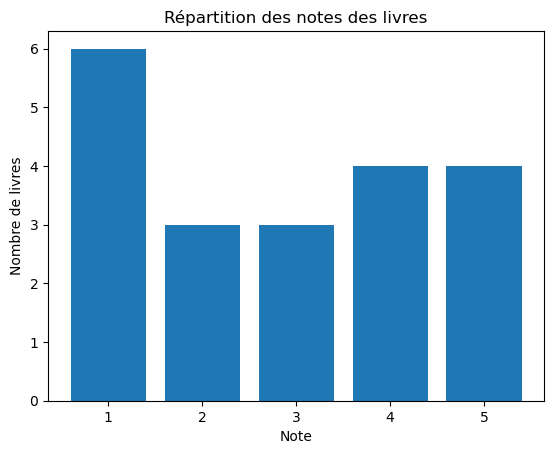

In [63]:
import matplotlib.pyplot as plt

plt.bar(nombre_par_note.index, nombre_par_note.values)

plt.xlabel("Note")
plt.ylabel("Nombre de livres")
plt.title("Répartition des notes des livres")

plt.show()

In [64]:
for numero_page in range(1,51):
        print(numero_page)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50


In [65]:
for numero_page in range(1, 51):
    url = f"https://books.toscrape.com/catalogue/page-{numero_page}.html"
    print(url)

https://books.toscrape.com/catalogue/page-1.html
https://books.toscrape.com/catalogue/page-2.html
https://books.toscrape.com/catalogue/page-3.html
https://books.toscrape.com/catalogue/page-4.html
https://books.toscrape.com/catalogue/page-5.html
https://books.toscrape.com/catalogue/page-6.html
https://books.toscrape.com/catalogue/page-7.html
https://books.toscrape.com/catalogue/page-8.html
https://books.toscrape.com/catalogue/page-9.html
https://books.toscrape.com/catalogue/page-10.html
https://books.toscrape.com/catalogue/page-11.html
https://books.toscrape.com/catalogue/page-12.html
https://books.toscrape.com/catalogue/page-13.html
https://books.toscrape.com/catalogue/page-14.html
https://books.toscrape.com/catalogue/page-15.html
https://books.toscrape.com/catalogue/page-16.html
https://books.toscrape.com/catalogue/page-17.html
https://books.toscrape.com/catalogue/page-18.html
https://books.toscrape.com/catalogue/page-19.html
https://books.toscrape.com/catalogue/page-20.html
https://b

In [66]:
donnees_livres = []

for numero_page in range(1, 51):
    url = f"https://books.toscrape.com/catalogue/page-{numero_page}.html"

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    books = soup.find_all("article", class_="product_pod")

    for livre in books:
        titres = livre.find("h3")
        liens = titres.find("a")
        noms_livres = liens["title"]

        note = livre.find("p", class_="star-rating")
        classes_note = note["class"]
        note_livre = classes_note[1]
        notes_nombre = conversion_notes[note_livre]

        prix = livre.find("p", class_="price_color")
        prix_livres = prix.text
    
        donnees_livres.append({
        "Titre": noms_livres,
        "Prix": prix_livres,
        "Note": notes_nombre
    })
    
print(len(donnees_livres))

1000


In [67]:
df = pd.DataFrame(donnees_livres)
print(df)

                                                 Titre     Prix  Note
0                                 A Light in the Attic  Â£51.77     3
1                                   Tipping the Velvet  Â£53.74     1
2                                           Soumission  Â£50.10     1
3                                        Sharp Objects  Â£47.82     4
4                Sapiens: A Brief History of Humankind  Â£54.23     5
..                                                 ...      ...   ...
995  Alice in Wonderland (Alice's Adventures in Won...  Â£55.53     1
996   Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)  Â£57.06     4
997  A Spy's Devotion (The Regency Spies of London #1)  Â£16.97     5
998                1st to Die (Women's Murder Club #1)  Â£53.98     1
999                 1,000 Places to See Before You Die  Â£26.08     5

[1000 rows x 3 columns]


In [68]:
df.shape

(1000, 3)

In [70]:
df["Prix"] = df["Prix"].str.replace("Â£", "").astype(float)

In [71]:
df.dtypes

Titre     object
Prix     float64
Note       int64
dtype: object

In [74]:
prix_moyens_all = df["Prix"].mean()
prix_min_all = df["Prix"].min()
prix_max_all = df["Prix"].max()
note_par_livre = df["Note"].value_counts().sort_index()
note_moyenne_all = df["Note"].mean()

print(prix_moyens_all)
print(prix_min_all)
print(prix_max_all)
print(note_par_livre)
print(note_moyenne_all)

35.07035
10.0
59.99
Note
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64
2.923


In [75]:
prix_par_note = df.groupby("Note")["Prix"].mean()

print(prix_par_note)

Note
1    34.561195
2    34.810918
3    34.692020
4    36.093296
5    35.374490
Name: Prix, dtype: float64


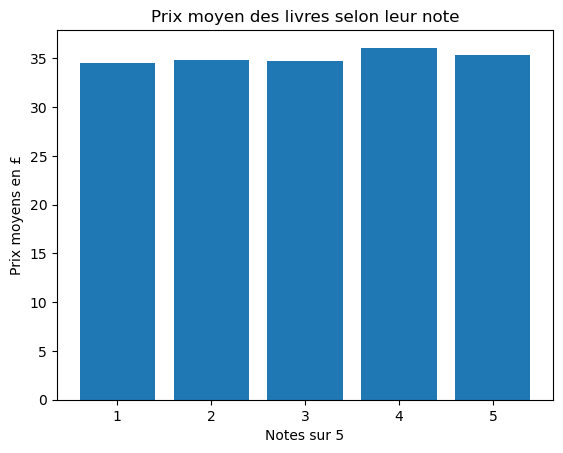

In [77]:
plt.bar(prix_par_note.index, prix_par_note.values)

plt.xlabel("Notes sur 5")
plt.ylabel("Prix moyens en £")
plt.title("Prix moyen des livres selon leur note")

plt.show()

In [79]:
df.to_csv(
    "livres_books_to_scrape.csv",
    index=False,
    encoding="utf-8-sig"
)
